# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Faiz Farrosian Karim| 5054251027|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_style('whitegrid')


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')

print('Jumlah baris dan kolom:', df.shape)
df.info()

print()
print('Statistik deskriptif:')
display(df.describe())

print()
print('Jumlah missing value (NaN) per kolom:')
print(df.isnull().sum())


Jumlah baris dan kolom: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Statistik deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Jumlah missing value (NaN) per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Outcome
0    500
1    268
Name: count, dtype: int64


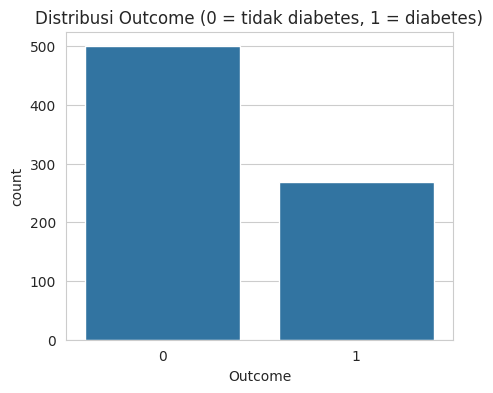

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df['Outcome'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Outcome (0 = tidak diabetes, 1 = diabetes)')
plt.show()


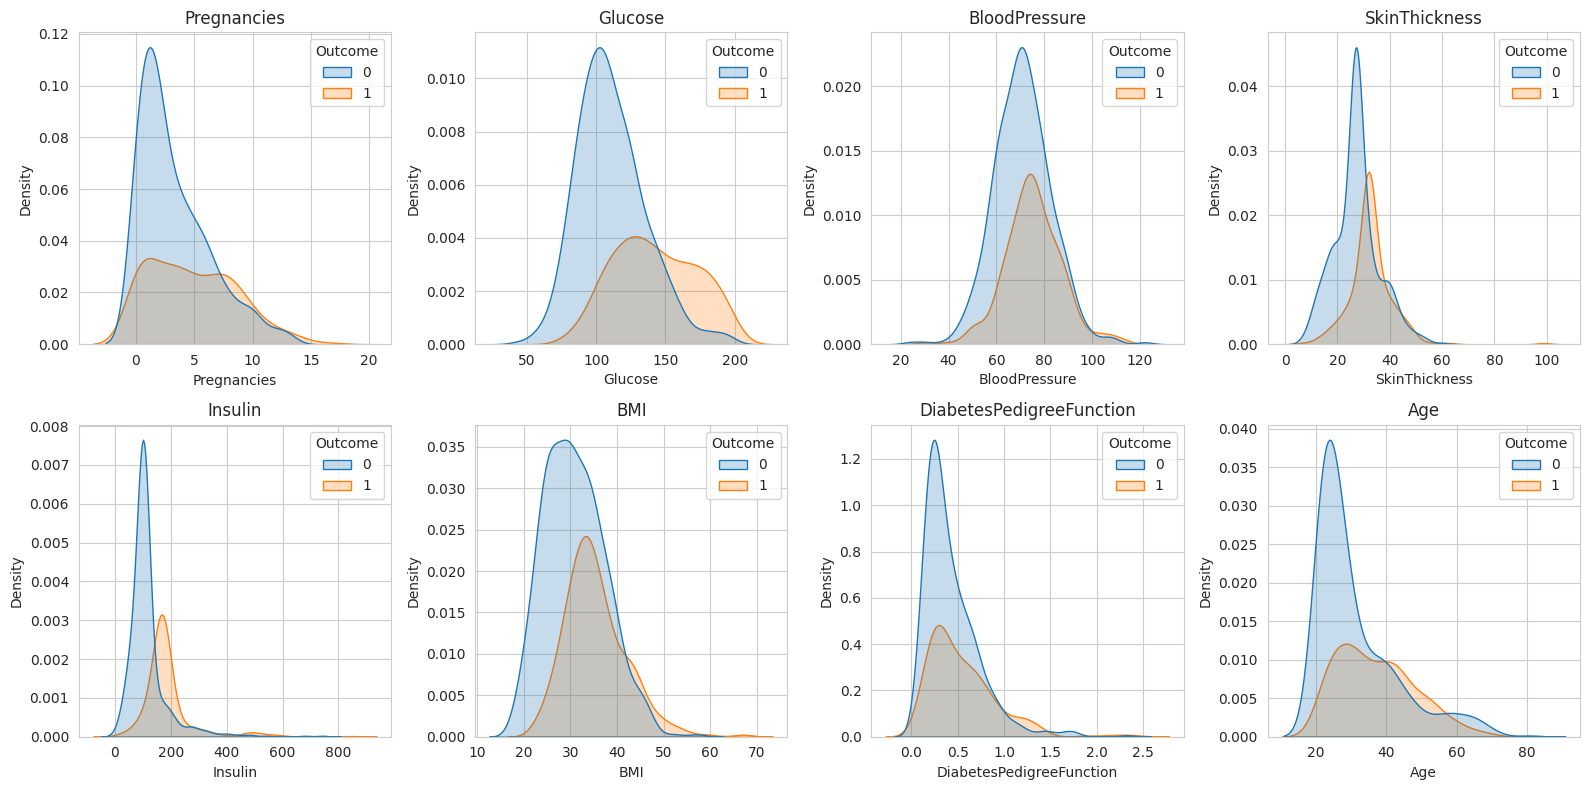

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
fitur = [kol for kol in df.columns if kol != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, kol in zip(axes, fitur):
    sns.kdeplot(data=df, x=kol, hue='Outcome', fill=True, ax=ax)
    ax.set_title(kol)

plt.tight_layout()
plt.show()


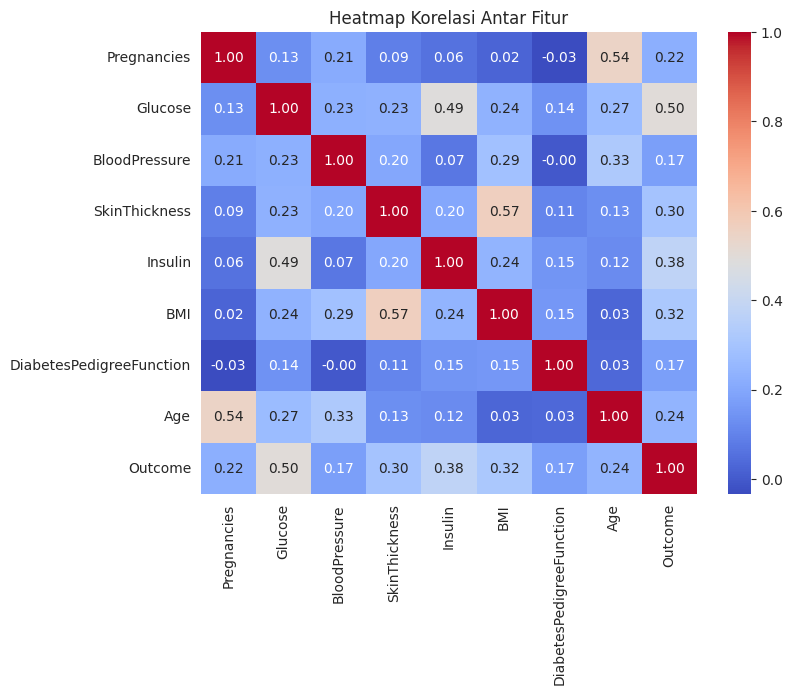

In [5]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


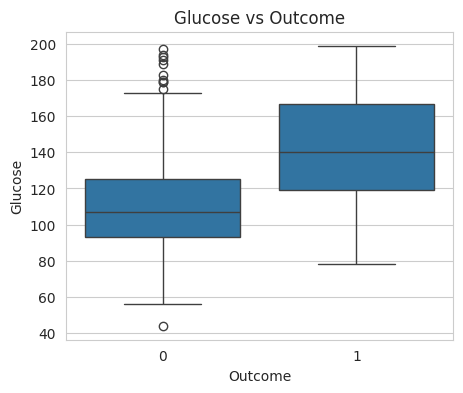

In [6]:
# EDA tambahan: lihat boxplot Glucose terhadap Outcome,
# karena kadar glukosa biasanya berkaitan erat dengan diabetes.
plt.figure(figsize=(5,4))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose vs Outcome')
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
kolom_tidak_boleh_nol = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for kol in kolom_tidak_boleh_nol:
    jumlah_nol = (df[kol] == 0).sum()
    print(f'{kol}: {jumlah_nol} nilai 0')


Glucose: 0 nilai 0
BloodPressure: 0 nilai 0
SkinThickness: 0 nilai 0
Insulin: 0 nilai 0
BMI: 0 nilai 0


In [8]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Langkah 1: ubah nilai 0 pada kolom-kolom tersebut menjadi NaN (belum diisi apa-apa dulu, cuma ditandai sebagai missing).
df[kolom_tidak_boleh_nol] = df[kolom_tidak_boleh_nol].replace(0, np.nan)

print('Jumlah missing value setelah 0 diubah menjadi NaN:')
print(df[kolom_tidak_boleh_nol].isnull().sum())


Jumlah missing value setelah 0 diubah menjadi NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputasi nilai NaN memakai median dari TRAIN SET saja, lalu diterapkan ke train dan test.
# Ini supaya tidak ada informasi dari test set yang "bocor" ke proses training (data leakage).
for kol in kolom_tidak_boleh_nol:
    median_train = X_train[kol].median()
    X_train[kol] = X_train[kol].fillna(median_train)
    X_test[kol] = X_test[kol].fillna(median_train)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (614, 8)
X_test : (154, 8)


In [10]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])


[[-0.85135507 -1.0568694  -0.82668697 -1.8952899  -1.17037761 -0.76615019
   0.31079384 -0.79216928]
 [ 0.35657564  0.1428554   0.4770088  -0.22473578 -1.42764161 -0.41444809
  -0.11643851  0.56103382]
 [-0.5493724  -0.55698407 -1.15261091  1.22307779 -0.54559361  0.36222739
  -0.76486207 -0.70759409]
 [-0.85135507  0.80936917 -1.31557289 -0.22473578 -0.44146295 -0.39979383
   0.26231357 -0.36929331]
 [-1.15333775 -0.89024096 -0.663725    1.11170751 -0.41083628  1.78369005
  -0.33762972 -0.96131967]]


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
model_gnb = GaussianNB()
model_gnb.fit(X_train_scaled, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = model_gnb.predict(X_test_scaled)
y_proba_gnb = model_gnb.predict_proba(X_test_scaled)[:, 1]


## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
model_logreg = LogisticRegression(random_state=42)
model_logreg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_logreg = model_logreg.predict(X_test_scaled)
y_proba_logreg = model_logreg.predict_proba(X_test_scaled)[:, 1]


# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
hasil = {
    'Model': ['Gaussian NB', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_logreg),
    ],
    'Precision': [
        precision_score(y_test, y_pred_gnb),
        precision_score(y_test, y_pred_logreg),
    ],
    'Recall': [
        recall_score(y_test, y_pred_gnb),
        recall_score(y_test, y_pred_logreg),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gnb),
        f1_score(y_test, y_pred_logreg),
    ],
}

df_hasil = pd.DataFrame(hasil)
df_hasil


,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


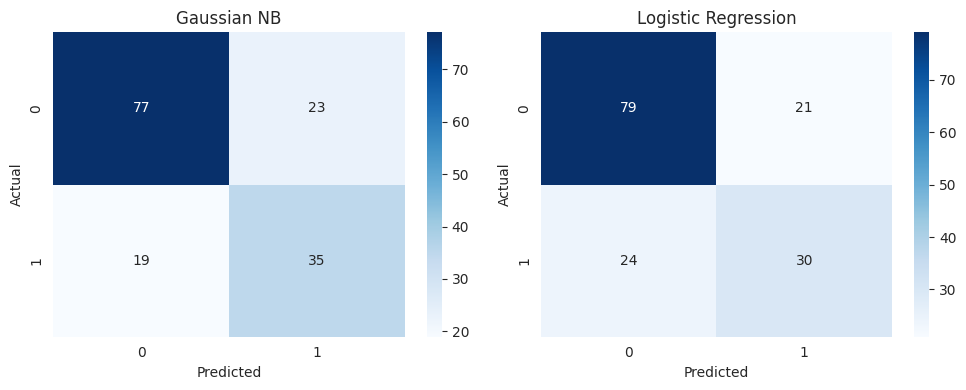

In [16]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

preds = [y_pred_gnb, y_pred_logreg]
judul = ['Gaussian NB', 'Logistic Regression']

for ax, pred, title in zip(axes, preds, judul):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


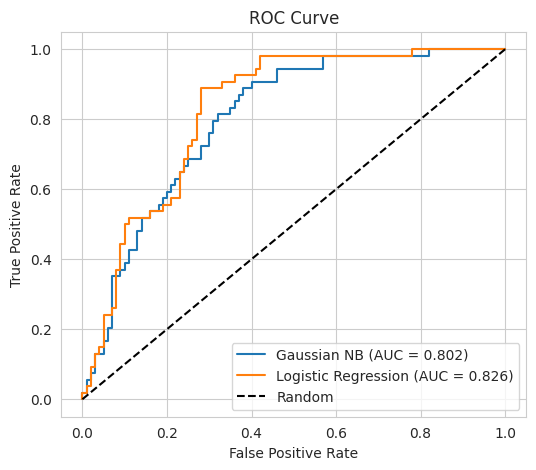

In [17]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
probas = [y_proba_gnb, y_proba_logreg]

plt.figure(figsize=(6, 5))
for proba, title in zip(probas, judul):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{title} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


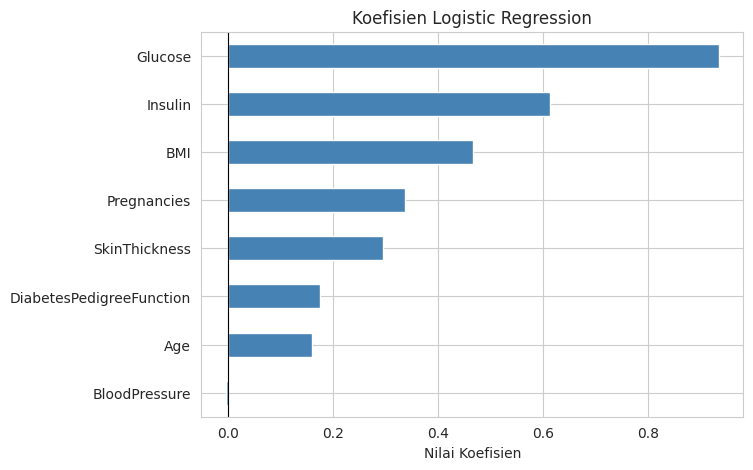

In [18]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
koef = pd.Series(model_logreg.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
koef.plot(kind='barh', color='steelblue')
plt.title('Koefisien Logistic Regression')
plt.xlabel('Nilai Koefisien')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Dari hasil eksperimen di atas, performa kedua model tidak terlalu jauh berbeda, tetapi Gaussian Naive Bayes justru sedikit lebih unggul dari sisi Accuracy, Recall, dan F1-Score:

- **Gaussian NB**: Accuracy 0.727, Precision 0.603, Recall 0.648, F1-Score 0.625
- **Logistic Regression**: Accuracy 0.708, Precision 0.588, Recall 0.556, F1-Score 0.571

Namun jika dilihat dari AUC, Logistic Regression sedikit lebih baik (AUC 0.826) dibanding Gaussian NB (AUC 0.802). Artinya, secara keseluruhan kemampuan Logistic Regression dalam membedakan pasien diabetes dan tidak diabetes (di berbagai threshold) sedikit lebih baik, meskipun pada threshold default 0.5 performanya justru sedikit kalah dari Gaussian NB.

Recall pada kedua model masih tergolong rendah (di bawah 0.65), yang berarti masih banyak pasien diabetes yang tidak terdeteksi oleh model (false negative). Ini kemungkinan disebabkan oleh dataset yang tidak terlalu besar (768 baris) dan sedikit imbalanced (jumlah pasien non-diabetes lebih banyak dari pasien diabetes), sehingga model cenderung lebih "hati-hati" dalam memprediksi kelas diabetes.

Dari bar chart koefisien Logistic Regression, fitur **Glucose** memiliki koefisien positif paling besar, diikuti oleh **Insulin** dan **BMI**. Ini sesuai dengan pengetahuan medis umum bahwa kadar glukosa darah yang tinggi adalah indikator utama diabetes, dan juga terlihat jelas pada KDE plot di tahap EDA di mana distribusi Glucose pasien diabetes cenderung bergeser ke nilai yang lebih tinggi. Sebaliknya, fitur BloodPressure memiliki koefisien yang mendekati nol, yang berarti kontribusinya terhadap prediksi diabetes pada model ini sangat kecil.

Perbedaan performa kedua model kemungkinan berasal dari asumsi yang digunakan: Gaussian NB mengasumsikan tiap fitur berdistribusi normal dan saling independen antar fitur (yang belum tentu benar, misalnya BMI dan SkinThickness kemungkinan berkorelasi), sedangkan Logistic Regression tidak mengasumsikan independensi antar fitur sehingga lebih fleksibel menangkap hubungan antar fitur, namun tetap terbatas karena hanya memodelkan hubungan linear terhadap log-odds target.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
1. Kedua model (Gaussian NB dan Logistic Regression) mampu mengklasifikasikan diabetes dengan performa yang cukup baik namun belum terlalu tinggi, dengan accuracy sekitar 71-73% dan AUC sekitar 0.80-0.83.
2. Gaussian NB sedikit lebih unggul pada Accuracy, Recall, dan F1-Score di threshold default, sedangkan Logistic Regression sedikit lebih unggul dari sisi AUC.
3. Fitur Glucose, Insulin, dan BMI adalah fitur yang paling berpengaruh terhadap prediksi diabetes berdasarkan koefisien Logistic Regression, sedangkan BloodPressure hampir tidak berkontribusi.
4. Recall pada kedua model masih tergolong rendah, sehingga model ini belum ideal untuk dipakai sebagai alat skrining awal di dunia nyata karena risiko banyak pasien diabetes yang tidak terdeteksi.

**Saran untuk eksperimen selanjutnya:**
- Mencoba threshold klasifikasi yang berbeda (bukan 0.5) untuk menaikkan Recall, karena pada kasus medis mendeteksi pasien diabetes (mengurangi false negative) biasanya lebih penting daripada precision.
- Menangani ketidakseimbangan kelas dengan teknik seperti class_weight='balanced' pada Logistic Regression atau oversampling (misalnya SMOTE).
- Mencoba model lain seperti Random Forest atau SVM untuk melihat apakah performa bisa lebih baik dibanding Gaussian NB dan Logistic Regression.